# 1. Import Library & Konfigurasi Utama

In [ ]:
import os
import random
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Rescaling
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

# Konfigurasi Utama
DATASET_DIR = Path("Dataset")
TARGET_SIZE = (128, 128)  # Lebar, Tinggi gambar
BATCH_SIZE = 16
EPOCHS = 20
SPLIT_RATIO = 0.2

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

print(f"Kelas ditemukan ({NUM_CLASSES}): {CLASS_NAMES}")

Kelas ditemukan (6): ['100k', '10k', '20k', '2k', '50k', '5k']


# 2. Pipeline Preprocessing OpenCV

In [ ]:
def preprocess_opencv(image_bgr):
    if image_bgr is None:
        return np.zeros((*TARGET_SIZE, 3), dtype=np.float32)
    
    # A. HSV Masking
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Fill Holes
    flood = mask.copy()
    flood_mask = np.zeros((mask.shape[0] + 2, mask.shape[1] + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    mask = mask | cv2.bitwise_not(flood)
    
    # Ambil Komponen Terbesar
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)
    if num_labels > 1:
        largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        if stats[largest_idx, cv2.CC_STAT_AREA] >= int(0.01 * mask.shape[0] * mask.shape[1]):
            refined[labels == largest_idx] = 255
    
    use_mask = refined if num_labels > 1 else mask
    segmented = cv2.bitwise_and(image_bgr, image_bgr, mask=use_mask)
    
    # B. Cropping Berdasarkan Mask
    coords = cv2.findNonZero(use_mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = int(max(w, h) * 0.05)
        image_bgr = segmented[
            max(y-pad, 0):min(y+h+pad, image_bgr.shape[0]), 
            max(x-pad, 0):min(x+w+pad, image_bgr.shape[1])
        ]
    
    # C. Resize dengan Padding (Letterbox)
    h, w = image_bgr.shape[:2]
    scale = min(TARGET_SIZE[0] / w, TARGET_SIZE[1] / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image_bgr, (nw, nh), interpolation=cv2.INTER_AREA)
    
    output = np.zeros((*TARGET_SIZE, 3), dtype=np.uint8)
    xo, yo = (TARGET_SIZE[0] - nw) // 2, (TARGET_SIZE[1] - nh) // 2
    output[yo:yo+nh, xo:xo+nw] = resized
    
    # D. Konversi Warna & Normalisasi [0, 1]
    return cv2.cvtColor(output, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

def tf_parse_wrapper(file_path, label):
    [image,] = tf.py_function(lambda p: preprocess_opencv(cv2.imread(p.numpy().decode('utf-8'))), [file_path], [tf.float32])
    image.set_shape((*TARGET_SIZE, 3))
    return image, tf.one_hot(label, NUM_CLASSES)

# 3. Manajemen Data & Pemisahan Dataset

In [ ]:
all_paths, all_labels = [], []
for cls_name in CLASS_NAMES:
    paths = [str(p) for p in (DATASET_DIR / cls_name).glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]
    all_paths.extend(paths)
    all_labels.extend([class_to_idx[cls_name]] * len(paths))

# Shuffle Data
combined = list(zip(all_paths, all_labels))
random.shuffle(combined)
all_paths, all_labels = zip(*combined)

split_idx = int(len(all_paths) * (1 - SPLIT_RATIO))

# Membangun tf.data.Dataset Pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((list(all_paths[:split_idx]), list(all_labels[:split_idx]))) \
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE).shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((list(all_paths[split_idx:]), list(all_labels[split_idx:]))) \
    .map(tf_parse_wrapper, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 4. Arsitektur Model (Transfer Learning) & Training

In [ ]:
tf.keras.backend.clear_session()

# Load MobileNetV2 Pre-trained Model
base_model = MobileNetV2(input_shape=(*TARGET_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False  

model = Sequential([
    Input(shape=(*TARGET_SIZE, 3)),
    Rescaling(scale=2.0, offset=-1.0),  
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax', dtype='float32')
], name="MobileNetV2_Transfer_Learning")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "MobileNetV2_Transfer_Learning"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 mobilenetv2_1.00_128 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 6

In [ ]:
# Memulai Proses Training
history = model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# Menyimpan Hasil Bobot
os.makedirs('saved_models', exist_ok=True)
model.save_weights('saved_models/mobilenet_weights.h5')
print("✅ Bobot model tersimpan di: saved_models/mobilenet_weights.h5")

Epoch 1/20
10/10 [==============================] - 30s 1s/step - loss: 1.9869 - accuracy: 0.2745 - val_loss: 1.2072 - val_accuracy: 0.4872
Epoch 2/20
10/10 [==============================] - 23s 965ms/step - loss: 1.2288 - accuracy: 0.5425 - val_loss: 0.8150 - val_accuracy: 0.7692
Epoch 3/20
10/10 [==============================] - 23s 965ms/step - loss: 0.8651 - accuracy: 0.6928 - val_loss: 0.5727 - val_accuracy: 0.9231
Epoch 4/20
10/10 [==============================] - 24s 1s/step - loss: 0.6490 - accuracy: 0.8366 - val_loss: 0.5071 - val_accuracy: 0.7692
Epoch 5/20
10/10 [==============================] - 24s 1s/step - loss: 0.5120 - accuracy: 0.8889 - val_loss: 0.4790 - val_accuracy: 0.7949
Epoch 6/20
10/10 [==============================] - 24s 966ms/step - loss: 0.4601 - accuracy: 0.8627 - val_loss: 0.3976 - val_accuracy: 0.8462
Epoch 7/20
10/10 [==============================] - 23s 974ms/step - loss: 0.3295 - accuracy: 0.9150 - val_loss: 0.3362 - val_accuracy: 0.8205
Epoch 8/

# 5. Evaluasi Metrik & Visualisasi

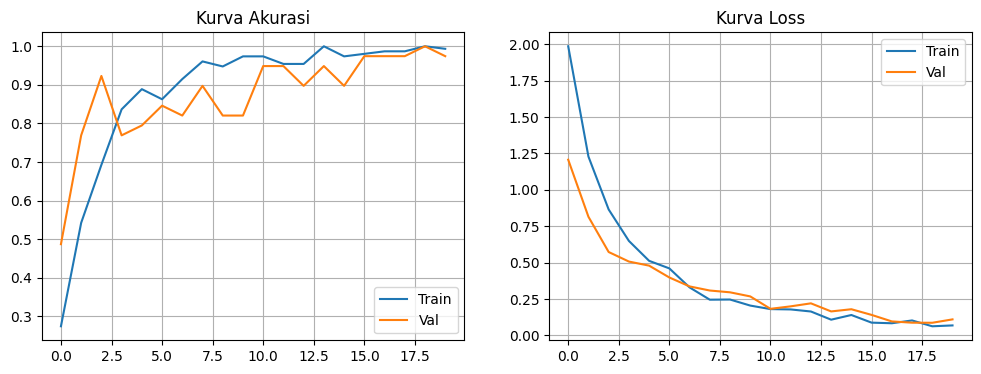

In [ ]:
# Plot Akurasi & Loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Kurva Akurasi')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title('Kurva Loss')
ax[1].legend()
ax[1].grid(True)
plt.show()

In [ ]:
# Ekstraksi Prediksi Data Validasi
y_true, y_pred = [], []
for imgs, labels in val_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(model.predict(imgs, verbose=0), axis=1))

# Tampilkan Laporan Klasifikasi Akhir
print("\n📊 CLASSIFICATION REPORT:\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


📊 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

        100k       1.00      1.00      1.00         8
         10k       1.00      0.89      0.94         9
         20k       1.00      1.00      1.00         4
          2k       0.75      1.00      0.86         3
         50k       1.00      1.00      1.00         6
          5k       1.00      1.00      1.00         9

    accuracy                           0.97        39
   macro avg       0.96      0.98      0.97        39
weighted avg       0.98      0.97      0.98        39



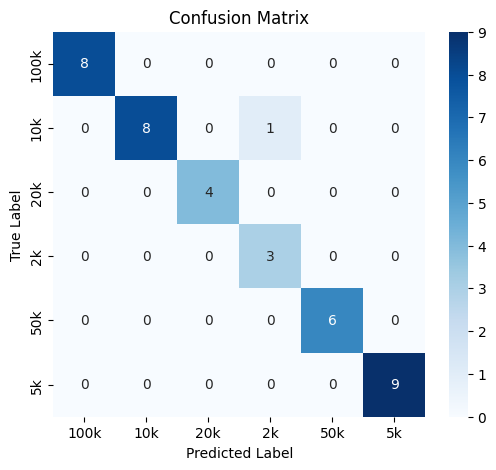

In [ ]:
# Tampilkan Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()